In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
# загрузка файла с одним листом
file_path = r'C:\Users\silen\OneDrive\Рабочий стол\учеба\СОИ\пр4\hcpi_m.xlsx'

# Чтение файла
df = pd.read_excel(file_path)

# проверяем структуру
df.head()

,Country Code,IMF Country Code,Country,Indicator Type,Series Name,197001,197002,197003,197004,197005,...,202408,202409,202410,202411,202412,202501,202502,202503,Data source,Note
0,ABW,314.0,Aruba,Index,Headline Consumer Price Index,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IFS,NaN
1,AFG,512.0,Afghanistan,Index,Headline Consumer Price Index,NaN,NaN,NaN,NaN,NaN,...,125.809803,126.488546,127.263109,126.780158,128.366370,128.508266,NaN,NaN,IFS,NaN
2,AGO,614.0,Angola,Index,Headline Consumer Price Index,NaN,NaN,NaN,NaN,NaN,...,207.504380,210.879490,214.157277,217.594986,221.293056,224.993357,NaN,NaN,National sources,NaN
3,ALB,914.0,Albania,Index,Headline Consumer Price Index,NaN,NaN,NaN,NaN,NaN,...,116.775018,117.505130,117.630071,117.603379,118.251031,118.684513,119.053412,NaN,IFS,NaN
4,ARE,466.0,United Arab Emirates,Index,Headline Consumer Price Index,NaN,NaN,NaN,NaN,NaN,...,108.820028,108.698979,108.362584,108.748894,108.849868,NaN,NaN,NaN,IFS,NaN


In [31]:
# выбираем Японию
japan = df[
    (df['Country'] == 'Japan') &
    (df['Series Name'] == 'Headline Consumer Price Index')
]

# выбор строки для Японии
japan = df[
    (df['Country'] == 'Japan') &
    (df['Series Name'] == 'Headline Consumer Price Index')
]

# выделение месячных столбцов
date_cols = [c for c in japan.columns if isinstance(c, int)]
japan_ts = japan[date_cols].T
japan_ts.columns = ['HCPI']
japan_ts.index = pd.to_datetime(japan_ts.index.astype(str), format='%Y%m')
japan_ts = japan_ts.sort_index().dropna()

# показать первые и последние строки
display(japan_ts.head())
display(japan_ts.tail())


,HCPI
1970-01-01,30.257409
1970-02-01,30.355648
1970-03-01,30.650363
1970-04-01,30.945078
1970-05-01,30.748601


,HCPI
2024-10-01,109.5
2024-11-01,110.0
2024-12-01,110.7
2025-01-01,111.2
2025-02-01,110.8


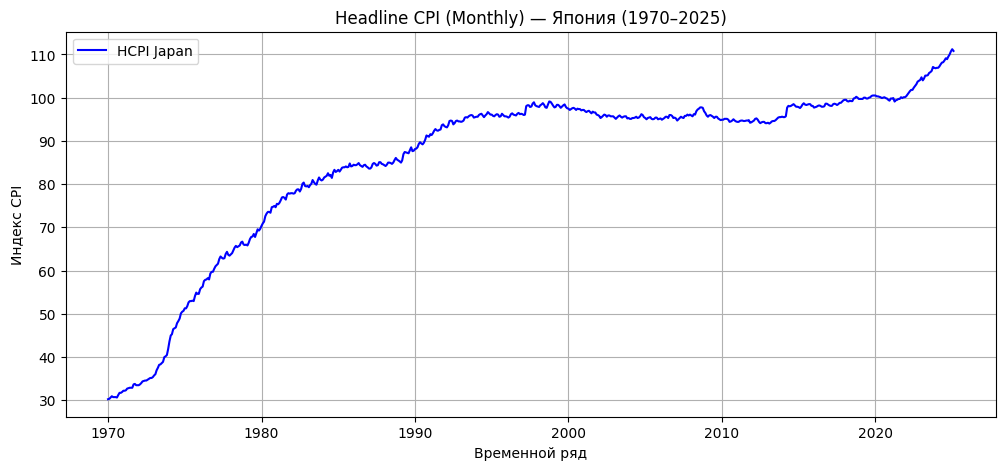

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(japan_ts.index, japan_ts['HCPI'], color='blue', label='HCPI Japan')
plt.xlabel('Временной ряд')
plt.ylabel('Индекс CPI')
plt.title('Headline CPI (Monthly) — Япония (1970–2025)')
plt.legend()
plt.grid(True)
plt.show()

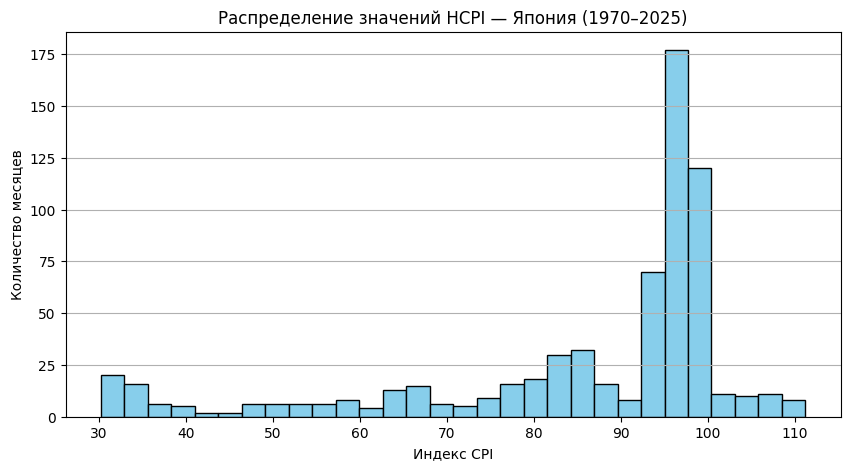

In [33]:
plt.figure(figsize=(10,5))
plt.hist(japan_ts['HCPI'], bins=30, color='skyblue', edgecolor='black')
plt.xlabel('Индекс CPI')
plt.ylabel('Количество месяцев')
plt.title('Распределение значений HCPI — Япония (1970–2025)')
plt.grid(axis='y')
plt.show()

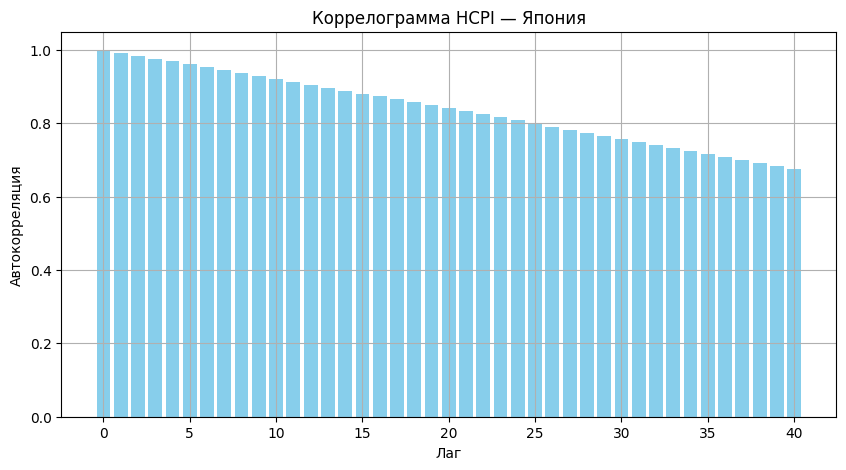

ADF Statistic: -3.2034245222153044
p-value: 0.019787308193442318


In [34]:
from statsmodels.tsa.stattools import acf, adfuller

# 1. Автокорреляции
lag_acf = acf(japan_ts['HCPI'], nlags=40)  # до 40 месяцев
lags = range(len(lag_acf))

# 2. Построение коррелограммы
plt.figure(figsize=(10,5))
plt.bar(lags, lag_acf, color='skyblue')
plt.xlabel('Лаг')
plt.ylabel('Автокорреляция')
plt.title('Коррелограмма HCPI — Япония')
plt.grid(True)
plt.show()

# 3. Дополнительно: тест Дики-Фуллера
adf_result = adfuller(japan_ts['HCPI'])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])


In [35]:
from statsmodels.stats.stattools import durbin_watson
import statsmodels.api as sm

# Добавим константу для регрессии на тренд
t = range(len(japan_ts))
X = sm.add_constant(t)
y = japan_ts['HCPI']

# Линейная регрессия ряда по времени
model = sm.OLS(y, X).fit()

# Тест Дарбина-Уотсона
dw_stat = durbin_watson(model.resid)
print("Durbin-Watson statistic:", dw_stat)


Durbin-Watson statistic: 0.0014048080727716119


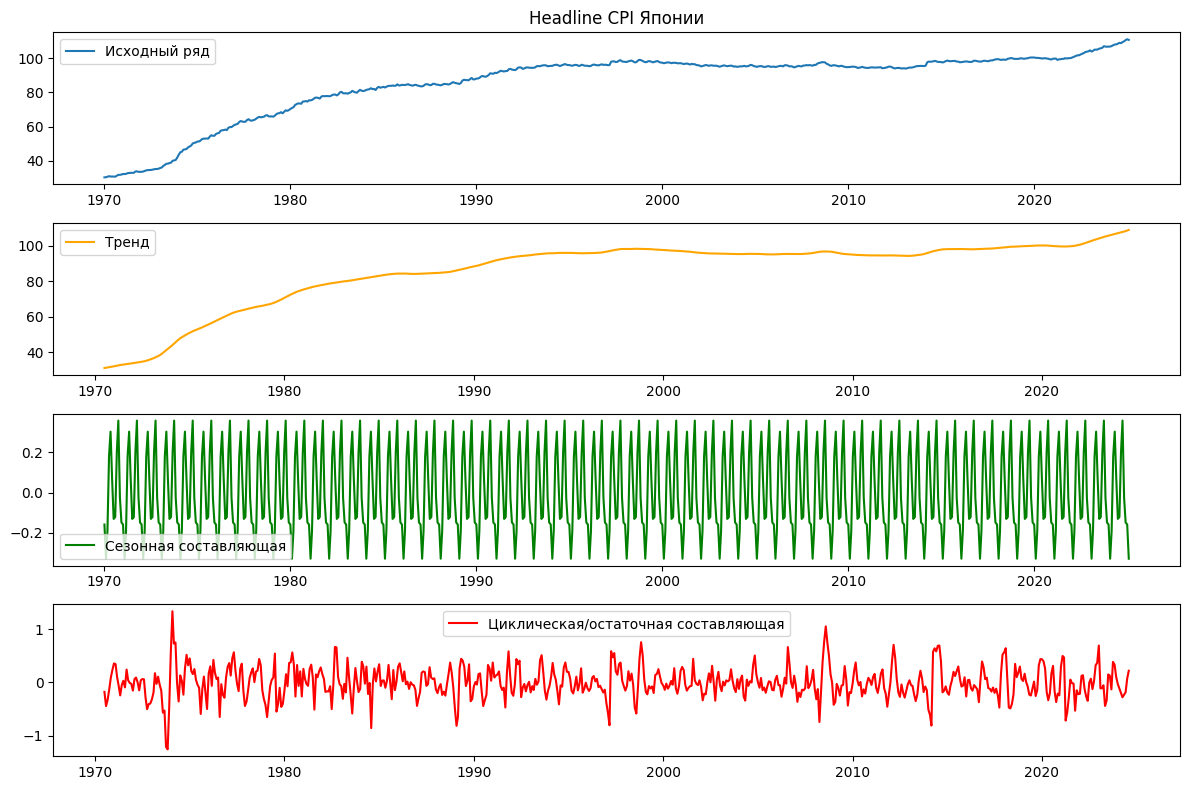

In [36]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Разложение ряда (additive — сложение компонентов)
decomposition = seasonal_decompose(japan_ts['HCPI'], model='additive', period=12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Графики
plt.figure(figsize=(12,8))

plt.subplot(4,1,1)
plt.plot(japan_ts.index, japan_ts['HCPI'], label='Исходный ряд')
plt.title('Headline CPI Японии')
plt.legend()

plt.subplot(4,1,2)
plt.plot(trend, label='Тренд', color='orange')
plt.legend()

plt.subplot(4,1,3)
plt.plot(seasonal, label='Сезонная составляющая', color='green')
plt.legend()

plt.subplot(4,1,4)
plt.plot(residual, label='Циклическая/остаточная составляющая', color='red')
plt.legend()

plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
from statsmodels.tsa.seasonal import seasonal_decompose

# Разложение ряда (месячные данные, период=12)
decomposition = seasonal_decompose(japan_ts['HCPI'], model='additive', period=12)

# Создаём таблицу
components = pd.DataFrame({
    'CPI': japan_ts['HCPI'],
    'Trend': decomposition.trend,
    'Seasonal': decomposition.seasonal,
    'Residual': decomposition.resid
})

# Добавляем проверку суммы
components['Sum_Check'] = components['Trend'] + components['Seasonal'] + components['Residual']

# Выводим первые и последние 5 строк
print("Начало ряда:")
print(components.head())
print("\nКонец ряда:")
print(components.tail())


Начало ряда:
                  CPI  Trend  Seasonal  Residual  Sum_Check
1970-01-01  30.257409    NaN -0.158794       NaN        NaN
1970-02-01  30.355648    NaN -0.328744       NaN        NaN
1970-03-01  30.650363    NaN -0.191873       NaN        NaN
1970-04-01  30.945078    NaN  0.180857       NaN        NaN
1970-05-01  30.748601    NaN  0.303002       NaN        NaN

Конец ряда:
              CPI  Trend  Seasonal  Residual  Sum_Check
2024-10-01  109.5    NaN  0.358026       NaN        NaN
2024-11-01  110.0    NaN -0.025259       NaN        NaN
2024-12-01  110.7    NaN -0.148442       NaN        NaN
2025-01-01  111.2    NaN -0.158794       NaN        NaN
2025-02-01  110.8    NaN -0.328744       NaN        NaN


In [38]:
components_clean = components.dropna()
components_clean.index = components_clean.index.to_period('M')
# Вывод первых и последних 5 строк
print("Начало ряда без NaN:")
print(components_clean.head())
print("\nКонец ряда:")
print(components_clean.tail())

Начало ряда без NaN:
               CPI      Trend  Seasonal  Residual  Sum_Check
1970-07  30.748601  31.059689 -0.130872 -0.180216  30.748601
1970-08  30.650363  31.219326 -0.121721 -0.447243  30.650363
1970-09  31.239793  31.366684  0.198945 -0.325837  31.239793
1970-10  31.730984  31.509948  0.358026 -0.136989  31.730984
1970-11  31.730984  31.669585 -0.025259  0.086658  31.730984

Конец ряда:
           CPI       Trend  Seasonal  Residual  Sum_Check
2024-04  107.7  107.800000  0.180857 -0.280857      107.7
2024-05  108.1  108.029167  0.303002 -0.232169      108.1
2024-06  108.2  108.320833  0.064875 -0.185709      108.2
2024-07  108.6  108.662500 -0.130872  0.068372      108.6
2024-08  109.1  109.004167 -0.121721  0.217554      109.1


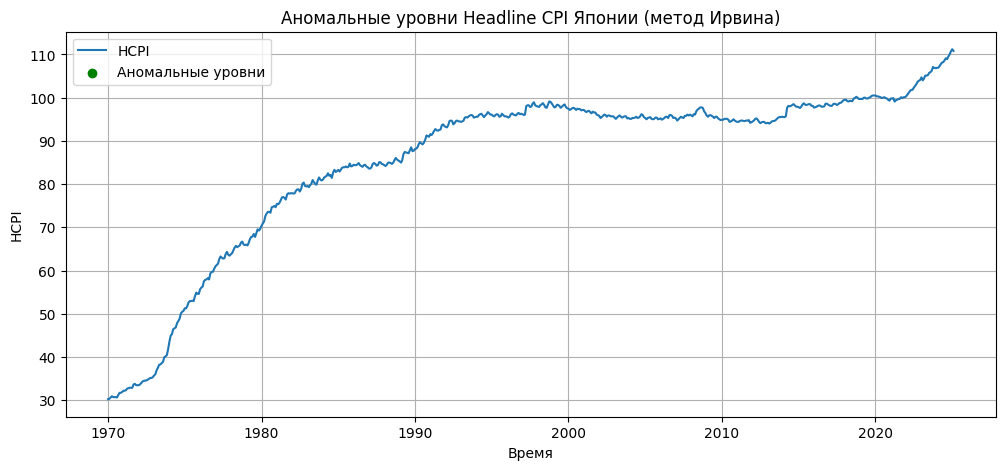

In [48]:
df_irwin = japan_ts.copy()

df_irwin['Delta'] = df_irwin['HCPI'].diff()

s = df_irwin['HCPI'].std()

df_irwin['Irwin_stat'] = df_irwin['Delta'].abs() / s

I_crit = 1.5

df_irwin['Anomaly'] = df_irwin['Irwin_stat'] > I_crit

anomalies = df_irwin[df_irwin['Anomaly']]

plt.figure(figsize=(12, 5))
plt.plot(df_irwin.index, df_irwin['HCPI'], label='HCPI')
plt.scatter(anomalies.index, anomalies['HCPI'], label='Аномальные уровни', color = 'green', zorder=5)
plt.title('Аномальные уровни Headline CPI Японии (метод Ирвина)')
plt.xlabel('Время')
plt.ylabel('HCPI')
plt.legend()
plt.grid(True)
plt.show()

In [40]:
df_irwin['Anomaly'].sum()

np.int64(2)

In [41]:
df_irwin[['HCPI', 'Delta', 'Irwin_stat']].head(10)

,HCPI,Delta,Irwin_stat
1970-01-01,30.257409,NaN,NaN
1970-02-01,30.355648,0.098238,0.005081
1970-03-01,30.650363,0.294715,0.015242
1970-04-01,30.945078,0.294715,0.015242
1970-05-01,30.748601,-0.196477,0.010161
1970-06-01,30.748601,0.000000,0.000000
1970-07-01,30.748601,0.000000,0.000000
1970-08-01,30.650363,-0.098238,0.005081
1970-09-01,31.239793,0.589430,0.030484
1970-10-01,31.730984,0.491192,0.025403


In [42]:
# метод сравнения средних
n = len(japan_ts)
first_half = japan_ts['HCPI'].iloc[:n//2]
second_half = japan_ts['HCPI'].iloc[n//2:]

mean_first = first_half.mean()
mean_second = second_half.mean()

mean_first, mean_second

(np.float64(73.38493182849898), np.float64(97.94750716152967))

In [43]:
# метод Фостера–Стюарта
diff = japan_ts['HCPI'].diff().dropna()

S = diff.sum()
sigma = diff.std()

FS_stat = S / sigma
FS_stat


np.float64(203.16395690953092)

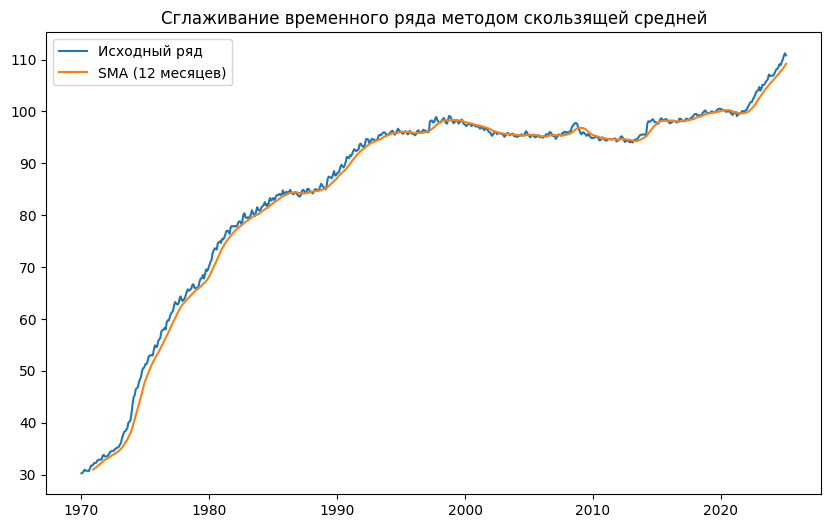

In [44]:
# простая скользящая средняя (12 месяцев)
japan_ts['SMA_12'] = japan_ts['HCPI'].rolling(window=12).mean()

# визуализация
plt.figure(figsize=(10, 6))
plt.plot(japan_ts['HCPI'], label='Исходный ряд')
plt.plot(japan_ts['SMA_12'], label='SMA (12 месяцев)')
plt.legend()
plt.title('Сглаживание временного ряда методом скользящей средней')
plt.show()

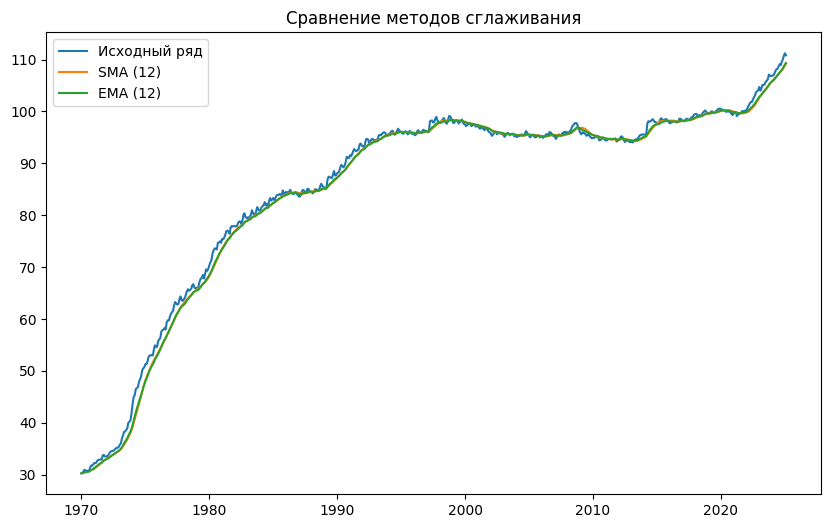

In [45]:
# экспоненциальное сглаживание
japan_ts['EMA_12'] = japan_ts['HCPI'].ewm(span=12, adjust=False).mean()

plt.figure(figsize=(10, 6))
plt.plot(japan_ts['HCPI'], label='Исходный ряд')
plt.plot(japan_ts['SMA_12'], label='SMA (12)')
plt.plot(japan_ts['EMA_12'], label='EMA (12)')
plt.legend()
plt.title('Сравнение методов сглаживания')
plt.show()


In [46]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

t = np.arange(len(japan_ts))
y = japan_ts['HCPI'].values

# 1. Линейная модель
lin_coef = np.polyfit(t, y, 1)
y_lin = np.polyval(lin_coef, t)

# 2. Полиномиальная 2 степени
poly2_coef = np.polyfit(t, y, 2)
y_poly2 = np.polyval(poly2_coef, t)

# 3. Экспоненциальная модель
log_y = np.log(y)
exp_coef = np.polyfit(t, log_y, 1)
y_exp = np.exp(exp_coef[1]) * np.exp(exp_coef[0] * t)

# Метрики
models = {
    'Линейная': y_lin,
    'Полиномиальная (2)': y_poly2,
    'Экспоненциальная': y_exp
}

for name, y_hat in models.items():
    r2 = r2_score(y, y_hat)
    rmse = np.sqrt(mean_squared_error(y, y_hat))
    print(f'{name}: R² = {r2:.4f}, RMSE = {rmse:.2f}')


Линейная: R² = 0.6986, RMSE = 10.61
Полиномиальная (2): R² = 0.9139, RMSE = 5.67
Экспоненциальная: R² = 0.5648, RMSE = 12.75


Линейная модель:
Параметры: a = 0.084503, b = 57.738138
Формула: y = 0.084503 * t + 57.738138
R² = 0.699, RMSE = 10.61

Полиномиальная модель 2-й степени:
Параметры: a = -2.744713e-04, b = 0.265928, c = 37.781329
Формула: y = -2.744713e-04 * t² + 0.265928 * t + 37.781329
R² = 0.914, RMSE = 5.67

Экспоненциальная модель:
Параметры: a = 519865.715807, b = 0.000000, c = -519807.976580
Формула: y = 519865.715807 * exp(0.000000 * t) + -519807.976580
R² = 0.699, RMSE = 10.61



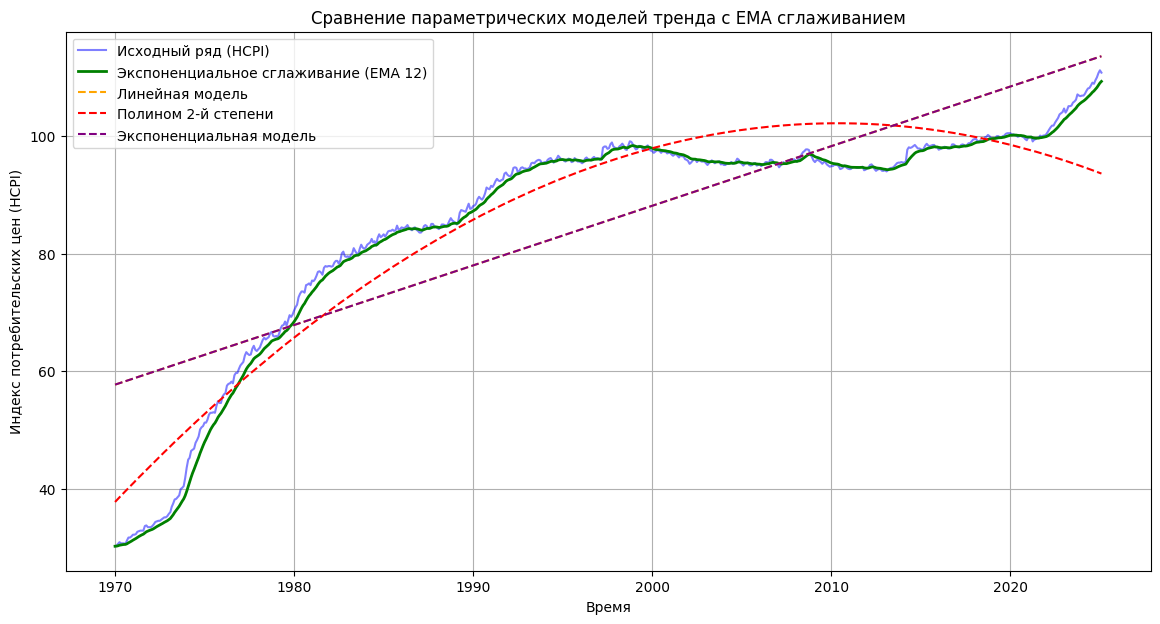

In [50]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Предполагаем, что данные загружены в DataFrame japan_ts с колонкой 'HCPI' и индексом datetime
# Например: japan_ts = pd.read_csv('your_data_file.csv', index_col='Date', parse_dates=True)
# y = japan_ts['HCPI'].values  # Если нужно, раскомментируйте и адаптируйте под ваш код

# Для примера используем placeholder; замените на ваши реальные данные
# Если данные уже в переменной, используйте их

# Вычисление EMA (экспоненциального сглаживания) с периодом 12
ema = japan_ts['HCPI'].ewm(span=12, adjust=False).mean()

# Временная переменная t как последовательные номера наблюдений
t = np.arange(len(japan_ts))

# 1. Линейная модель: y = a * t + b
lin_coeffs = np.polyfit(t, japan_ts['HCPI'], 1)
lin_hat = np.polyval(lin_coeffs, t)

# 2. Полиномиальная модель 2-й степени: y = a * t^2 + b * t + c
poly_coeffs = np.polyfit(t, japan_ts['HCPI'], 2)
poly_hat = np.polyval(poly_coeffs, t)

# 3. Экспоненциальная модель: y = a * exp(b * t) + c
def exp_func(t, a, b, c):
    return a * np.exp(b * t) + c

# Начальные приближения (подберите, если не сходится; на основе данных ~30 to ~110)
popt, pcov = curve_fit(exp_func, t, japan_ts['HCPI'], p0=(80, 0.0005, 30), maxfev=10000)
exp_hat = exp_func(t, *popt)

# Функция для расчёта метрик
def calculate_metrics(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, rmse

# Метрики для каждой модели
lin_r2, lin_rmse = calculate_metrics(japan_ts['HCPI'], lin_hat)
poly_r2, poly_rmse = calculate_metrics(japan_ts['HCPI'], poly_hat)
exp_r2, exp_rmse = calculate_metrics(japan_ts['HCPI'], exp_hat)

# Вывод параметров и формул
print("Линейная модель:")
print(f"Параметры: a = {lin_coeffs[0]:.6f}, b = {lin_coeffs[1]:.6f}")
print(f"Формула: y = {lin_coeffs[0]:.6f} * t + {lin_coeffs[1]:.6f}")
print(f"R² = {lin_r2:.3f}, RMSE = {lin_rmse:.2f}\n")

print("Полиномиальная модель 2-й степени:")
print(f"Параметры: a = {poly_coeffs[0]:.6e}, b = {poly_coeffs[1]:.6f}, c = {poly_coeffs[2]:.6f}")
print(f"Формула: y = {poly_coeffs[0]:.6e} * t² + {poly_coeffs[1]:.6f} * t + {poly_coeffs[2]:.6f}")
print(f"R² = {poly_r2:.3f}, RMSE = {poly_rmse:.2f}\n")

print("Экспоненциальная модель:")
print(f"Параметры: a = {popt[0]:.6f}, b = {popt[1]:.6f}, c = {popt[2]:.6f}")
print(f"Формула: y = {popt[0]:.6f} * exp({popt[1]:.6f} * t) + {popt[2]:.6f}")
print(f"R² = {exp_r2:.3f}, RMSE = {exp_rmse:.2f}\n")

# Построение общего графика
plt.figure(figsize=(14, 7))
plt.plot(japan_ts.index, japan_ts['HCPI'], label='Исходный ряд (HCPI)', color='blue', alpha=0.5)
plt.plot(japan_ts.index, ema, label='Экспоненциальное сглаживание (EMA 12)', color='green', linewidth=2)
plt.plot(japan_ts.index, lin_hat, label='Линейная модель', color='orange', linestyle='--')
plt.plot(japan_ts.index, poly_hat, label='Полином 2-й степени', color='red', linestyle='--')
plt.plot(japan_ts.index, exp_hat, label='Экспоненциальная модель', color='purple', linestyle='--')

plt.title('Сравнение параметрических моделей тренда с EMA сглаживанием')
plt.xlabel('Время')
plt.ylabel('Индекс потребительских цен (HCPI)')
plt.legend()
plt.grid(True)
plt.show()

ЛИНЕЙНАЯ МОДЕЛЬ
Уравнение: HCPI(t) = 57.7381 + 0.0845 * t
Параметры: a = 57.7381, b = 0.0845
R² = 0.6986
MSE = 112.5304

КВАДРАТИЧНАЯ МОДЕЛЬ
Уравнение: HCPI(t) = 37.7813 + 0.2659 * t + -0.0003 * t²
Параметры: a = 37.7813, b = 0.2659, c = -0.0003
R² = 0.9139
MSE = 32.1503

ЭКСПОНЕНЦИАЛЬНАЯ МОДЕЛЬ
Уравнение: HCPI(t) = 62.8008 * exp(0.000899 * t)
Параметры: a = 62.8008, b = 0.000899
R² = 0.6368
MSE = 135.5751

СТЕПЕННАЯ МОДЕЛЬ
Уравнение: HCPI(t) = 20.1957 * t^0.2579
Параметры: a = 20.1957, b = 0.2579
R² = 0.9061
MSE = 35.0460

СРАВНЕНИЕ МОДЕЛЕЙ
          Модель       R²        MSE                                 Уравнение
        Линейная 0.698560 112.530397                HCPI(t) = 57.74 + 0.0845·t
    Квадратичная 0.913878  32.150326 HCPI(t) = 37.78 + 0.2659·t + -0.000274·t²
Экспоненциальная 0.636829 135.575130            HCPI(t) = 62.80·e^{0.000899·t}
       Степенная 0.906121  35.045985                HCPI(t) = 20.20·t^{0.2579}

Лучшая модель: Квадратичная (R² = 0.9139)


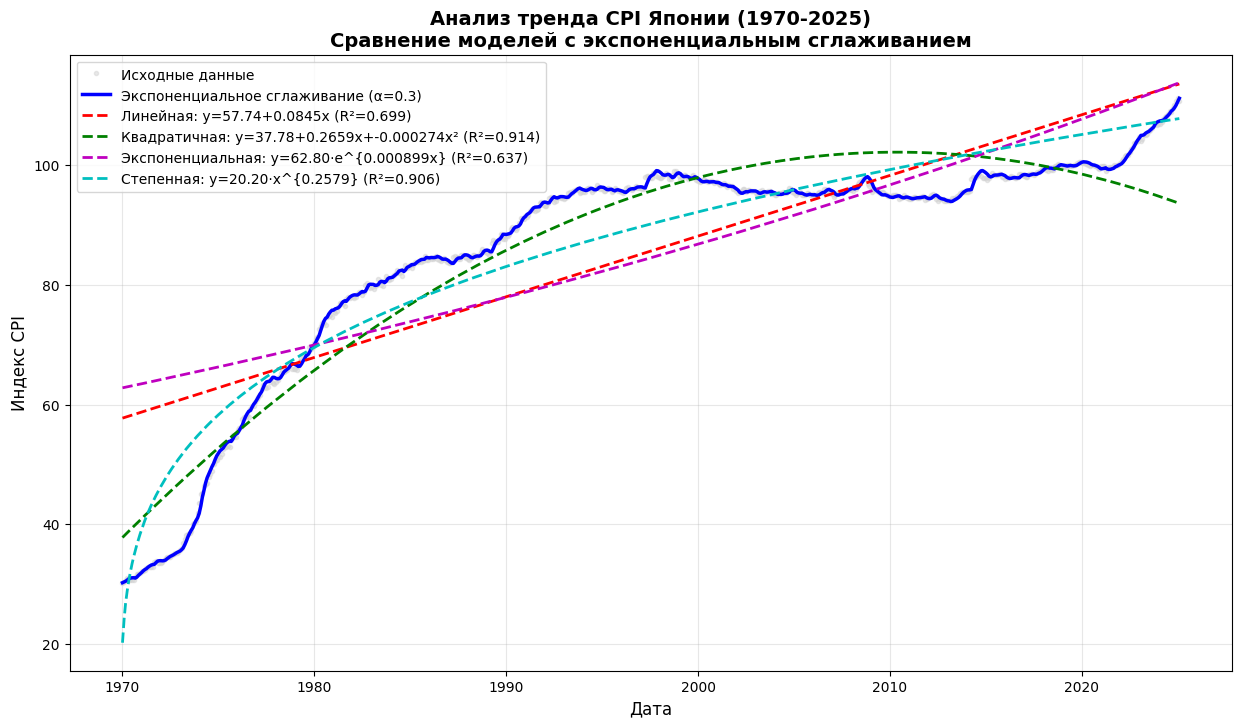

In [53]:
# ============================================
# ПУНКТ 1.9: Анализ тренда с построением моделей
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------
# 1. Подготовка данных
# -------------------------------------------------
# Используем уже подготовленный временной ряд Японии
ts = japan_ts.copy()

# Создаем числовой индекс для моделей (вместо дат)
# Преобразуем даты в числовые значения: 0, 1, 2, ...
ts_numeric = ts.reset_index()
ts_numeric['time_idx'] = np.arange(len(ts_numeric))

# -------------------------------------------------
# 2. Экспоненциальное сглаживание (Holt-Winters)
# -------------------------------------------------
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Параметры для экспоненциального сглаживания
alpha = 0.3  # параметр сглаживания

# Простое экспоненциальное сглаживание
exp_smoothing = ExponentialSmoothing(
    ts['HCPI'], 
    trend='add', 
    seasonal=None,
    initialization_method='estimated'
).fit(smoothing_level=alpha)

# Получаем сглаженные значения
ts['Exp_Smoothed'] = exp_smoothing.fittedvalues

# -------------------------------------------------
# 3. Подбор моделей тренда
# -------------------------------------------------

# Подготовим данные для моделей
X = ts_numeric['time_idx'].values.reshape(-1, 1)
y = ts_numeric['HCPI'].values

# 3.1 Линейная модель: y = a + b*x
from sklearn.linear_model import LinearRegression
linear_model = LinearRegression()
linear_model.fit(X, y)
linear_pred = linear_model.predict(X)

# Параметры линейной модели
a_lin = linear_model.intercept_
b_lin = linear_model.coef_[0]
print("=" * 60)
print("ЛИНЕЙНАЯ МОДЕЛЬ")
print("=" * 60)
print(f"Уравнение: HCPI(t) = {a_lin:.4f} + {b_lin:.4f} * t")
print(f"Параметры: a = {a_lin:.4f}, b = {b_lin:.4f}")
print(f"R² = {r2_score(y, linear_pred):.4f}")
print(f"MSE = {mean_squared_error(y, linear_pred):.4f}")
print()

# 3.2 Квадратичная модель: y = a + b*x + c*x²
# Создаем полиномиальные признаки
from sklearn.preprocessing import PolynomialFeatures
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)

quadratic_model = LinearRegression()
quadratic_model.fit(X_poly2, y)
quadratic_pred = quadratic_model.predict(X_poly2)

# Параметры квадратичной модели
a_quad = quadratic_model.intercept_
b_quad, c_quad = quadratic_model.coef_[1], quadratic_model.coef_[2]
print("=" * 60)
print("КВАДРАТИЧНАЯ МОДЕЛЬ")
print("=" * 60)
print(f"Уравнение: HCPI(t) = {a_quad:.4f} + {b_quad:.4f} * t + {c_quad:.4f} * t²")
print(f"Параметры: a = {a_quad:.4f}, b = {b_quad:.4f}, c = {c_quad:.4f}")
print(f"R² = {r2_score(y, quadratic_pred):.4f}")
print(f"MSE = {mean_squared_error(y, quadratic_pred):.4f}")
print()

# 3.3 Экспоненциальная модель: y = a * exp(b*x)
# Линеаризуем: ln(y) = ln(a) + b*x
from scipy.optimize import curve_fit

def exp_func(x, a, b):
    return a * np.exp(b * x)

# Используем curve_fit для нелинейной подгонки
try:
    popt_exp, pcov_exp = curve_fit(exp_func, X.flatten(), y, 
                                  p0=[y[0], 0.001], maxfev=5000)
    a_exp, b_exp = popt_exp
    exponential_pred = exp_func(X.flatten(), a_exp, b_exp)
    
    print("=" * 60)
    print("ЭКСПОНЕНЦИАЛЬНАЯ МОДЕЛЬ")
    print("=" * 60)
    print(f"Уравнение: HCPI(t) = {a_exp:.4f} * exp({b_exp:.6f} * t)")
    print(f"Параметры: a = {a_exp:.4f}, b = {b_exp:.6f}")
    print(f"R² = {r2_score(y, exponential_pred):.4f}")
    print(f"MSE = {mean_squared_error(y, exponential_pred):.4f}")
except Exception as e:
    print(f"Ошибка при подборе экспоненциальной модели: {e}")
    exponential_pred = None
    a_exp, b_exp = 0, 0
print()

# 3.4 Степенная модель: y = a * x^b
def power_func(x, a, b):
    return a * np.power(x, b)

try:
    # Избегаем x=0 для степенной модели
    X_power = X.flatten() + 1
    popt_power, pcov_power = curve_fit(power_func, X_power, y, 
                                      p0=[y[0], 0.1], maxfev=5000)
    a_pow, b_pow = popt_power
    power_pred = power_func(X_power, a_pow, b_pow)
    
    print("=" * 60)
    print("СТЕПЕННАЯ МОДЕЛЬ")
    print("=" * 60)
    print(f"Уравнение: HCPI(t) = {a_pow:.4f} * t^{b_pow:.4f}")
    print(f"Параметры: a = {a_pow:.4f}, b = {b_pow:.4f}")
    print(f"R² = {r2_score(y, power_pred):.4f}")
    print(f"MSE = {mean_squared_error(y, power_pred):.4f}")
except Exception as e:
    print(f"Ошибка при подборе степенной модели: {e}")
    power_pred = None
    a_pow, b_pow = 0, 0
print()

# -------------------------------------------------
# 4. Сравнение моделей
# -------------------------------------------------
print("=" * 60)
print("СРАВНЕНИЕ МОДЕЛЕЙ")
print("=" * 60)

models_comparison = pd.DataFrame({
    'Модель': ['Линейная', 'Квадратичная', 'Экспоненциальная', 'Степенная'],
    'R²': [
        r2_score(y, linear_pred),
        r2_score(y, quadratic_pred),
        r2_score(y, exponential_pred) if exponential_pred is not None else 0,
        r2_score(y, power_pred) if power_pred is not None else 0
    ],
    'MSE': [
        mean_squared_error(y, linear_pred),
        mean_squared_error(y, quadratic_pred),
        mean_squared_error(y, exponential_pred) if exponential_pred is not None else np.inf,
        mean_squared_error(y, power_pred) if power_pred is not None else np.inf
    ],
    'Уравнение': [
        f"HCPI(t) = {a_lin:.2f} + {b_lin:.4f}·t",
        f"HCPI(t) = {a_quad:.2f} + {b_quad:.4f}·t + {c_quad:.6f}·t²",
        f"HCPI(t) = {a_exp:.2f}·e^{{{b_exp:.6f}·t}}",
        f"HCPI(t) = {a_pow:.2f}·t^{{{b_pow:.4f}}}"
    ]
})

# Отображаем сравнение
print(models_comparison.to_string(index=False))

# Определяем лучшую модель по R²
best_model_idx = models_comparison['R²'].idxmax()
best_model_name = models_comparison.loc[best_model_idx, 'Модель']
best_model_r2 = models_comparison.loc[best_model_idx, 'R²']

print(f"\nЛучшая модель: {best_model_name} (R² = {best_model_r2:.4f})")

# -------------------------------------------------
# 5. График всех моделей
# -------------------------------------------------
plt.figure(figsize=(15, 8))

# Исходные данные
plt.plot(ts.index, ts['HCPI'], 'o', color='lightgray', alpha=0.5, 
         label='Исходные данные', markersize=3)

# Экспоненциальное сглаживание
plt.plot(ts.index, ts['Exp_Smoothed'], 'b-', linewidth=2.5, 
         label=f'Экспоненциальное сглаживание (α={alpha})')

# Линейная модель
plt.plot(ts.index, linear_pred, 'r--', linewidth=2, 
         label=f'Линейная: y={a_lin:.2f}+{b_lin:.4f}x (R²={r2_score(y, linear_pred):.3f})')

# Квадратичная модель
plt.plot(ts.index, quadratic_pred, 'g--', linewidth=2, 
         label=f'Квадратичная: y={a_quad:.2f}+{b_quad:.4f}x+{c_quad:.6f}x² (R²={r2_score(y, quadratic_pred):.3f})')

# Экспоненциальная модель (если есть)
if exponential_pred is not None:
    plt.plot(ts.index, exponential_pred, 'm--', linewidth=2, 
             label=f'Экспоненциальная: y={a_exp:.2f}·e^{{{b_exp:.6f}x}} (R²={r2_score(y, exponential_pred):.3f})')

# Степенная модель (если есть)
if power_pred is not None:
    plt.plot(ts.index, power_pred, 'c--', linewidth=2, 
             label=f'Степенная: y={a_pow:.2f}·x^{{{b_pow:.4f}}} (R²={r2_score(y, power_pred):.3f})')

# Настройка графика
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Индекс CPI', fontsize=12)
plt.title('Анализ тренда CPI Японии (1970-2025)\nСравнение моделей с экспоненциальным сглаживанием', 
          fontsize=14, fontweight='bold')
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)

КВАДРАТИЧНАЯ МОДЕЛЬ
Уравнение: HCPI(t) = 37.7813 + 0.265928·t + -0.00027447·t²

Параметры модели:
  a = 37.781329 (свободный член)
  b = 0.26592805 (линейный коэффициент)
  c = -0.0002744713 (квадратичный коэффициент)

Качество модели:
  R² = 0.913878
  MSE = 32.150326

ЭКСПОНЕНЦИАЛЬНАЯ МОДЕЛЬ
Уравнение: HCPI(t) = 62.8008·exp(0.00089935·t)

Параметры модели:
  a = 62.800819 (начальное значение)
  b = 0.0008993461 (темп роста)

Интерпретация:
  При t=0: HCPI(0) = 62.80
  Ежемесячный темп роста: 0.089975%

Качество модели:
  R² = 0.636829
  MSE = 135.575130

МОДЕЛЬ ГОМПЕРЦА
Уравнение: HCPI(t) = 98.8338·exp(-exp(-0.011335·(t-25.69)))

Параметры модели:
  a = 98.833816 (верхняя асимптота, предел роста)
  b = 0.01133477 (скорость роста)
  c = 25.69 (точка перегиба, где рост замедляется)

Интерпретация:
  Максимальное значение CPI: 98.83
  Точка перегиба на 26-м месяце наблюдения
  (примерно 1972-02-01 00:00:00)

Качество модели:
  R² = 0.980207
  MSE = 7.389056

ЛОГИСТИЧЕСКАЯ МОДЕЛЬ (Ферхюл

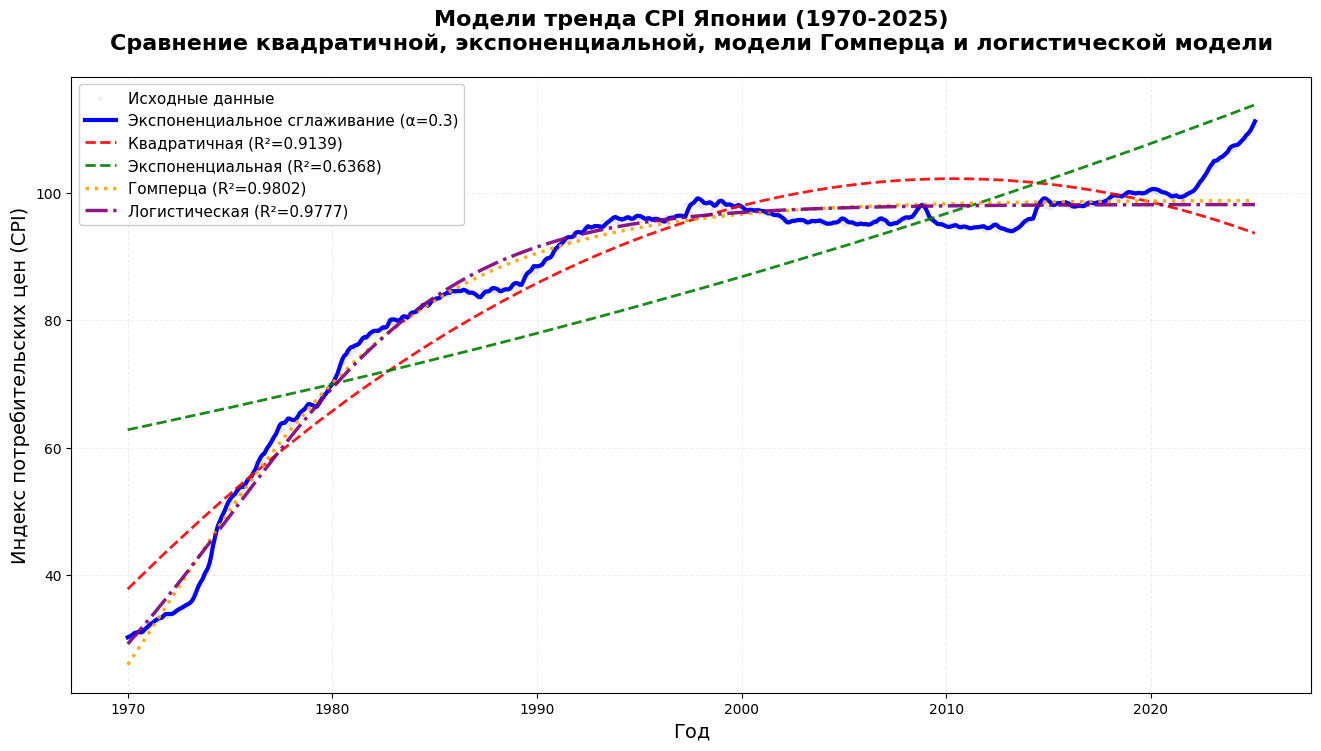

In [62]:
# ============================================
# ПУНКТ 1.9: Анализ тренда с построением моделей
# Квадратичная, экспоненциальная, Гомперца и логистическая
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from scipy.optimize import curve_fit
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

# -------------------------------------------------
# 1. Подготовка данных
# -------------------------------------------------
# Используем уже подготовленный временной ряд Японии
ts = japan_ts.copy()

# Создаем числовой индекс для моделей (вместо дат)
# Преобразуем даты в числовые значения: 0, 1, 2, ...
ts_numeric = ts.reset_index()
ts_numeric['time_idx'] = np.arange(len(ts_numeric))

# Подготовим данные для моделей
X = ts_numeric['time_idx'].values.reshape(-1, 1)
y = ts_numeric['HCPI'].values

# -------------------------------------------------
# 2. Экспоненциальное сглаживание (Holt-Winters)
# -------------------------------------------------
# Параметры для экспоненциального сглаживания
alpha = 0.3  # параметр сглаживания

# Простое экспоненциальное сглаживание
exp_smoothing = ExponentialSmoothing(
    ts['HCPI'], 
    trend='add', 
    seasonal=None,
    initialization_method='estimated'
).fit(smoothing_level=alpha)

# Получаем сглаженные значения
ts['Exp_Smoothed'] = exp_smoothing.fittedvalues

# -------------------------------------------------
# 3. Подбор моделей тренда
# -------------------------------------------------

# 3.1 КВАДРАТИЧНАЯ МОДЕЛЬ: y = a + b*x + c*x²
print("=" * 70)
print("КВАДРАТИЧНАЯ МОДЕЛЬ")
print("=" * 70)

# Создаем полиномиальные признаки степени 2
poly2 = PolynomialFeatures(degree=2)
X_poly2 = poly2.fit_transform(X)

quadratic_model = LinearRegression()
quadratic_model.fit(X_poly2, y)
quadratic_pred = quadratic_model.predict(X_poly2)

# Параметры квадратичной модели
a_quad = quadratic_model.intercept_
b_quad, c_quad = quadratic_model.coef_[1], quadratic_model.coef_[2]

print(f"Уравнение: HCPI(t) = {a_quad:.4f} + {b_quad:.6f}·t + {c_quad:.8f}·t²")
print("\nПараметры модели:")
print(f"  a = {a_quad:.6f} (свободный член)")
print(f"  b = {b_quad:.8f} (линейный коэффициент)")
print(f"  c = {c_quad:.10f} (квадратичный коэффициент)")
print(f"\nКачество модели:")
print(f"  R² = {r2_score(y, quadratic_pred):.6f}")
print(f"  MSE = {mean_squared_error(y, quadratic_pred):.6f}")
print()

# 3.2 ЭКСПОНЕНЦИАЛЬНАЯ МОДЕЛЬ: y = a * exp(b*x)
print("=" * 70)
print("ЭКСПОНЕНЦИАЛЬНАЯ МОДЕЛЬ")
print("=" * 70)

def exp_func(x, a, b):
    return a * np.exp(b * x)

exponential_pred = None
a_exp, b_exp = None, None

try:
    # Начальные приближения
    popt_exp, pcov_exp = curve_fit(exp_func, X.flatten(), y, 
                                  p0=[y[0], 0.001], 
                                  maxfev=5000)
    a_exp, b_exp = popt_exp
    exponential_pred = exp_func(X.flatten(), a_exp, b_exp)
    
    print(f"Уравнение: HCPI(t) = {a_exp:.4f}·exp({b_exp:.8f}·t)")
    print("\nПараметры модели:")
    print(f"  a = {a_exp:.6f} (начальное значение)")
    print(f"  b = {b_exp:.10f} (темп роста)")
    print(f"\nИнтерпретация:")
    print(f"  При t=0: HCPI(0) = {a_exp:.2f}")
    print(f"  Ежемесячный темп роста: {np.exp(b_exp)-1:.6%}")
    print(f"\nКачество модели:")
    print(f"  R² = {r2_score(y, exponential_pred):.6f}")
    print(f"  MSE = {mean_squared_error(y, exponential_pred):.6f}")
except Exception as e:
    print(f"Ошибка при подборе экспоненциальной модели: {e}")
    print("Модель не удалось подобрать для данных CPI Японии.")
print()

# 3.3 МОДЕЛЬ ГОМПЕРЦА: y = a * exp(-exp(-b*(t-c)))
print("=" * 70)
print("МОДЕЛЬ ГОМПЕРЦА")
print("=" * 70)

def gompertz_func(t, a, b, c):
    return a * np.exp(-np.exp(-b * (t - c)))

gompertz_pred = None
a_gomp, b_gomp, c_gomp = None, None, None

try:
    # Начальные приближения для параметров Гомперца
    a_init = np.max(y) * 1.1        # верхняя асимптота
    b_init = 0.01                   # скорость роста
    c_init = len(y) / 2            # точка перегиба
    
    popt_gomp, pcov_gomp = curve_fit(gompertz_func, X.flatten(), y, 
                                    p0=[a_init, b_init, c_init], 
                                    maxfev=10000,
                                    bounds=([0, 0, 0], 
                                           [np.max(y)*2, 1, len(y)*2]))
    
    a_gomp, b_gomp, c_gomp = popt_gomp
    gompertz_pred = gompertz_func(X.flatten(), a_gomp, b_gomp, c_gomp)
    
    print(f"Уравнение: HCPI(t) = {a_gomp:.4f}·exp(-exp(-{b_gomp:.6f}·(t-{c_gomp:.2f})))")
    print("\nПараметры модели:")
    print(f"  a = {a_gomp:.6f} (верхняя асимптота, предел роста)")
    print(f"  b = {b_gomp:.8f} (скорость роста)")
    print(f"  c = {c_gomp:.2f} (точка перегиба, где рост замедляется)")
    print(f"\nИнтерпретация:")
    print(f"  Максимальное значение CPI: {a_gomp:.2f}")
    print(f"  Точка перегиба на {c_gomp:.0f}-м месяце наблюдения")
    print(f"  (примерно {ts.index[int(c_gomp)]})")
    print(f"\nКачество модели:")
    print(f"  R² = {r2_score(y, gompertz_pred):.6f}")
    print(f"  MSE = {mean_squared_error(y, gompertz_pred):.6f}")
except Exception as e:
    print(f"Ошибка при подборе модели Гомперца: {e}")
    print("Модель Гомперца не удалось подобрать для данных CPI Японии.")
print()

# 3.4 ЛОГИСТИЧЕСКАЯ МОДЕЛЬ (Ферхюльста): y = a / (1 + exp(-b*(t-c)))
print("=" * 70)
print("ЛОГИСТИЧЕСКАЯ МОДЕЛЬ (Ферхюльста)")
print("=" * 70)

def logistic_func(t, a, b, c):
    return a / (1 + np.exp(-b * (t - c)))

logistic_pred = None
a_log, b_log, c_log = None, None, None

try:
    # Начальные приближения для логистической модели
    a_init = np.max(y) * 1.1        # верхняя асимптота
    b_init = 0.01                   # скорость роста
    c_init = len(y) / 2            # точка перегиба
    
    popt_log, pcov_log = curve_fit(logistic_func, X.flatten(), y, 
                                  p0=[a_init, b_init, c_init], 
                                  maxfev=10000,
                                  bounds=([0, 0, 0], 
                                         [np.max(y)*2, 1, len(y)*2]))
    
    a_log, b_log, c_log = popt_log
    logistic_pred = logistic_func(X.flatten(), a_log, b_log, c_log)
    
    print(f"Уравнение: HCPI(t) = {a_log:.4f} / (1 + exp(-{b_log:.6f}·(t-{c_log:.2f})))")
    print("\nПараметры модели:")
    print(f"  a = {a_log:.6f} (верхняя асимптота, предел роста)")
    print(f"  b = {b_log:.8f} (скорость роста)")
    print(f"  c = {c_log:.2f} (точка перегиба, середина S-образной кривой)")
    print(f"\nИнтерпретация:")
    print(f"  Максимальное значение CPI: {a_log:.2f}")
    print(f"  Точка перегиба на {c_log:.0f}-м месяце наблюдения")
    print(f"  (примерно {ts.index[int(c_log)]})")
    print(f"  Начальный темп роста: {b_log*a_log/4:.6f} единиц в месяц")
    print(f"\nКачество модели:")
    print(f"  R² = {r2_score(y, logistic_pred):.6f}")
    print(f"  MSE = {mean_squared_error(y, logistic_pred):.6f}")
except Exception as e:
    print(f"Ошибка при подборе логистической модели: {e}")
    print("Логистическая модель не удалось подобрать для данных CPI Японии.")
print()

# -------------------------------------------------
# 4. Сравнение всех моделей
# -------------------------------------------------
print("=" * 85)
print("СРАВНЕНИЕ МОДЕЛЕЙ ТРЕНДА ДЛЯ CPI ЯПОНИИ")
print("=" * 85)

# Создаем DataFrame для сравнения с проверкой на None
models_data = []
models_info = [
    ('Квадратичная', quadratic_pred, (a_quad, b_quad, c_quad)),
    ('Экспоненциальная', exponential_pred, (a_exp, b_exp, None) if a_exp is not None else (None, None, None)),
    ('Гомперца', gompertz_pred, (a_gomp, b_gomp, c_gomp) if a_gomp is not None else (None, None, None)),
    ('Логистическая', logistic_pred, (a_log, b_log, c_log) if a_log is not None else (None, None, None))
]

for name, pred, params in models_info:
    if pred is not None and params[0] is not None:
        # Форматируем уравнение в зависимости от модели
        if name == 'Квадратичная':
            equation = f"HCPI(t) = {params[0]:.2f} + {params[1]:.6f}·t + {params[2]:.8f}·t²"
        elif name == 'Экспоненциальная':
            equation = f"HCPI(t) = {params[0]:.2f}·exp({params[1]:.8f}·t)"
        elif name == 'Гомперца':
            equation = f"HCPI(t) = {params[0]:.2f}·exp(-exp(-{params[1]:.6f}·(t-{params[2]:.0f})))"
        elif name == 'Логистическая':
            equation = f"HCPI(t) = {params[0]:.2f}/(1+exp(-{params[1]:.6f}·(t-{params[2]:.0f})))"
        else:
            equation = "Н/Д"
        
        models_data.append({
            'Модель': name,
            'R²': r2_score(y, pred),
            'MSE': mean_squared_error(y, pred),
            'Уравнение': equation
        })

# Создаем DataFrame только если есть успешные модели
if models_data:
    models_comparison = pd.DataFrame(models_data)
    
    # Сортируем по R² (по убыванию)
    models_comparison = models_comparison.sort_values('R²', ascending=False)
    
    # Отображаем сравнение
    print("\nРейтинг моделей по качеству (лучшие сверху):")
    print("-" * 85)
    print(models_comparison.to_string(index=False))

# -------------------------------------------------
# 5. ГРАФИК ВСЕХ МОДЕЛЕЙ
# -------------------------------------------------
plt.figure(figsize=(16, 8))

# Цветовая схема для моделей
colors = {
    'Исходные данные': 'lightgray',
    'Эксп. сглаживание': 'blue',
    'Квадратичная': 'red',
    'Экспоненциальная': 'green',
    'Гомперца': 'orange',
    'Логистическая': 'purple'
}

# Стили линий
line_styles = {
    'Эксп. сглаживание': '-',
    'Квадратичная': '--',
    'Экспоненциальная': '--',
    'Гомперца': ':',
    'Логистическая': '-.'
}

# 1. Исходные данные (полупрозрачные точки)
plt.scatter(ts.index, ts['HCPI'], color=colors['Исходные данные'], 
           alpha=0.2, s=10, label='Исходные данные')

# 2. Экспоненциальное сглаживание (толстая линия)
plt.plot(ts.index, ts['Exp_Smoothed'], color=colors['Эксп. сглаживание'], 
         linestyle=line_styles['Эксп. сглаживание'], linewidth=3, 
         label=f'Экспоненциальное сглаживание (α={alpha})')

# 3. Квадратичная модель (всегда есть)
plt.plot(ts.index, quadratic_pred, color=colors['Квадратичная'], 
         linestyle=line_styles['Квадратичная'], linewidth=2, alpha=0.9,
         label=f'Квадратичная (R²={r2_score(y, quadratic_pred):.4f})')

# 4. Экспоненциальная модель (если есть)
if exponential_pred is not None:
    plt.plot(ts.index, exponential_pred, color=colors['Экспоненциальная'], 
             linestyle=line_styles['Экспоненциальная'], linewidth=2, alpha=0.9,
             label=f'Экспоненциальная (R²={r2_score(y, exponential_pred):.4f})')

# 5. Модель Гомперца (если есть)
if gompertz_pred is not None:
    plt.plot(ts.index, gompertz_pred, color=colors['Гомперца'], 
             linestyle=line_styles['Гомперца'], linewidth=2.5, alpha=0.9,
             label=f'Гомперца (R²={r2_score(y, gompertz_pred):.4f})')

# 6. Логистическая модель (если есть)
if logistic_pred is not None:
    plt.plot(ts.index, logistic_pred, color=colors['Логистическая'], 
             linestyle=line_styles['Логистическая'], linewidth=2.5, alpha=0.9,
             label=f'Логистическая (R²={r2_score(y, logistic_pred):.4f})')

# Настройка графика
plt.xlabel('Год', fontsize=14)
plt.ylabel('Индекс потребительских цен (CPI)', fontsize=14)
plt.title('Модели тренда CPI Японии (1970-2025)\n'
          'Сравнение квадратичной, экспоненциальной, модели Гомперца и логистической модели', 
          fontsize=16, fontweight='bold', pad=20)

# Легенда
plt.legend(loc='upper left', fontsize=11, framealpha=0.95)

# Сетка
plt.grid(True, alpha=0.2, linestyle='--')

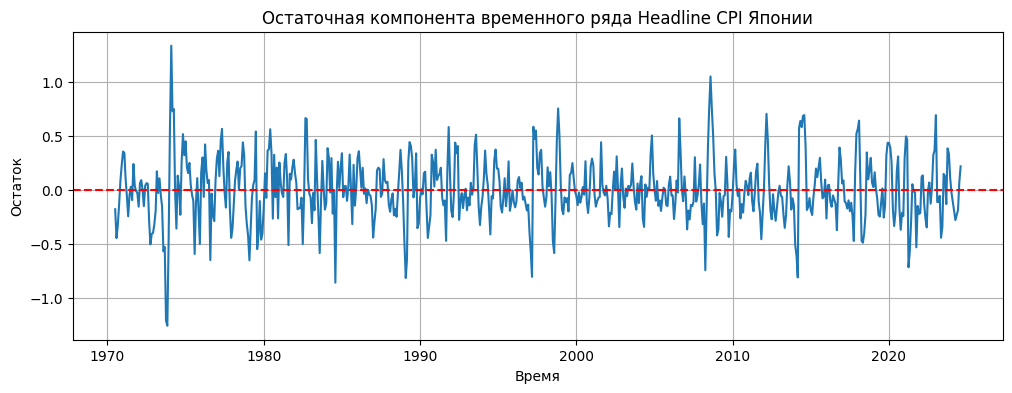

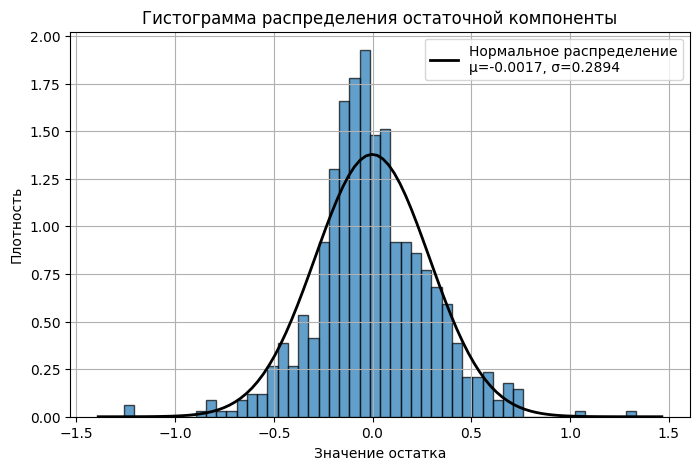

=== Оценка остаточной компоненты ===
Среднее значение остатка: -0.001741
Стандартное отклонение: 0.289415
Статистика Дарбина–Уотсона: 0.9599
Тест Шапиро–Уилка: статистика = 0.9805, p-value = 0.0000
Тест Льюнга–Бокса (lags=1–10):
       lb_stat     lb_pvalue
1   176.110814  3.424820e-40
2   182.700115  2.124096e-40
3   199.374785  5.757750e-43
4   252.909890  1.536993e-53
5   303.248989  2.005053e-63
6   327.105326  1.263504e-67
7   330.772648  1.602800e-67
8   330.798522  1.130743e-66
9   332.520419  3.238968e-66
10  334.536258  7.590380e-66


In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score

# График остаточной компоненты (Рисунок 10)
plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title('Остаточная компонента временного ряда Headline CPI Японии')
plt.xlabel('Время')
plt.ylabel('Остаток')
plt.grid(True)
plt.show()

# Гистограмма распределения остатков
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7, density=True)
plt.title('Гистограмма распределения остаточной компоненты')
plt.xlabel('Значение остатка')
plt.ylabel('Плотность')

# Наложение нормального распределения для визуального сравнения
mu, std = residuals.mean(), residuals.std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2, label=f'Нормальное распределение\nμ={mu:.4f}, σ={std:.4f}')
plt.legend()
plt.grid(True)
plt.show()

# Числовые характеристики и тесты
print("=== Оценка остаточной компоненты ===")
print(f"Среднее значение остатка: {residuals.mean():.6f}")
print(f"Стандартное отклонение: {residuals.std():.6f}")
print(f"Статистика Дарбина–Уотсона: {durbin_watson(residuals):.4f}")

# Тест Шапиро–Уилка на нормальность
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"Тест Шапиро–Уилка: статистика = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")

# Тест Льюнга–Бокса на автокорреляцию (до 10 лагов)
lb_test = acorr_ljungbox(residuals, lags=10, return_df=True)
print("Тест Льюнга–Бокса (lags=1–10):")
print(lb_test)